# Quantum Analysis Client

## Import and Check The Data

In [14]:
import pandas as pd
import numpy as np
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')
PH = pd.read_csv(r"C:\Users\acer\Downloads\QVI_purchase_behaviour.csv") #Purchase behaviour dataset
HD = pd.read_excel(r"C:\Users\acer\Downloads\QVI_transaction_data.xlsx") #Transaction dataset
display(PH.head())
display(HD.head())

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


## High Interpretation Analysis

In [15]:
display(PH.info())
display(HD.info())
display(PH.describe())
display(HD.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


None

,LYLTY_CARD_NBR
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


## Cleaning Data

### Correcting Dataset Format

In [16]:
HD['DATE'] = pd.to_datetime(HD['DATE'], unit='D', origin='1899-12-30')


In [17]:
HD.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


### Check Outliers

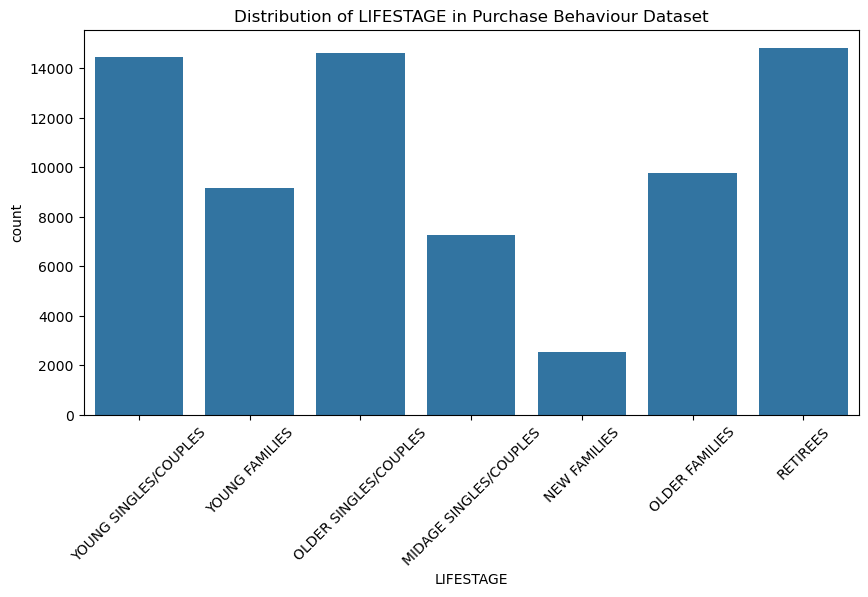

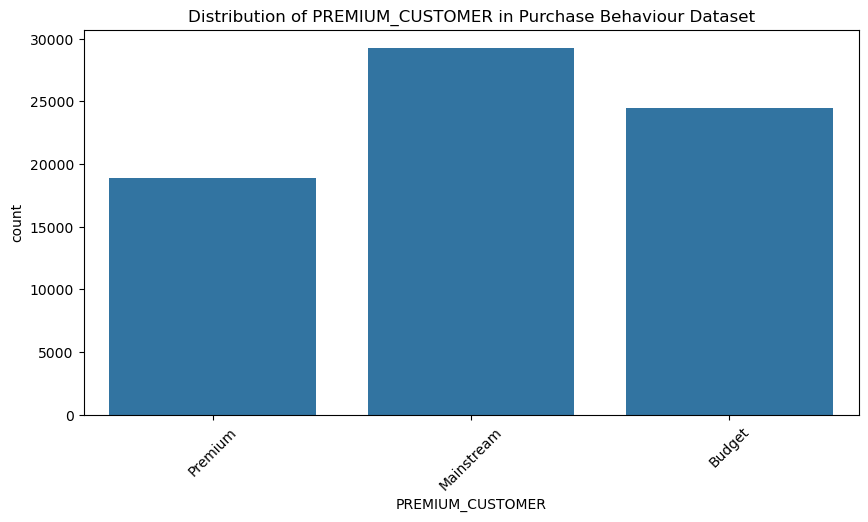

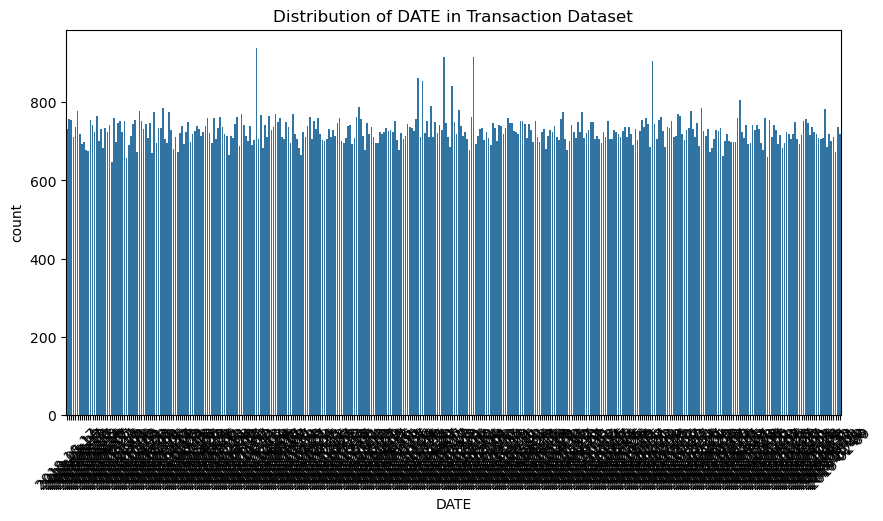

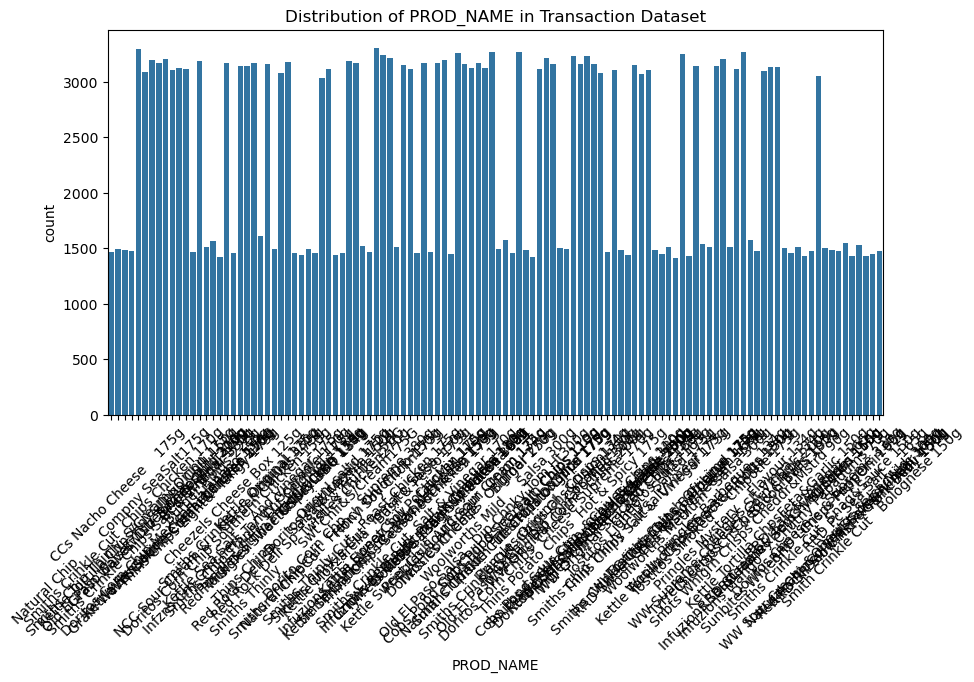

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
ph_category= PH.select_dtypes(exclude=[np.number])
hd_category= HD.select_dtypes(exclude=[np.number])
for col in ph_category.columns:
    plt.figure(figsize=(10,5))
    sns.countplot(data=ph_category, x=col)
    plt.title(f'Distribution of {col} in Purchase Behaviour Dataset')
    plt.xticks(rotation=45)
    plt.show()
for col in hd_category.columns:
    plt.figure(figsize=(10,5))
    sns.countplot(data=hd_category, x=col)
    plt.title(f'Distribution of {col} in Transaction Dataset')
    plt.xticks(rotation=45)
    plt.show()


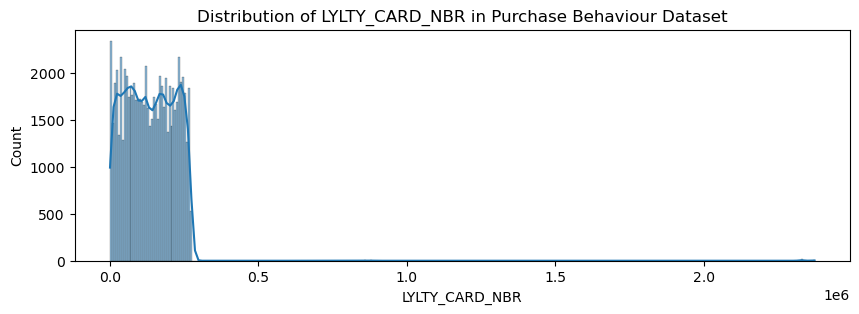

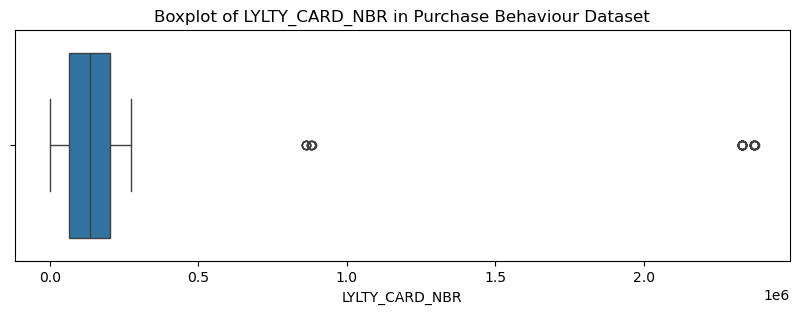

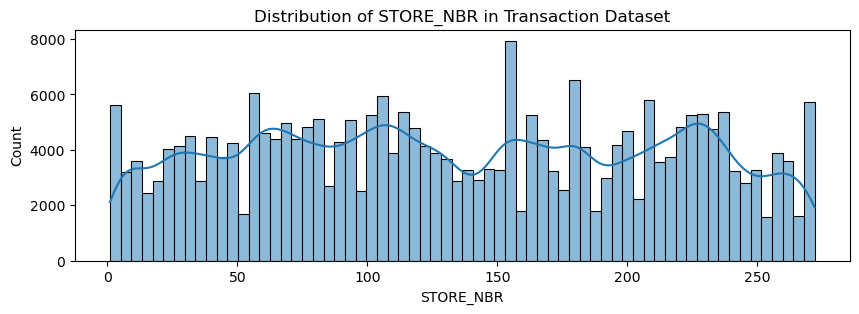

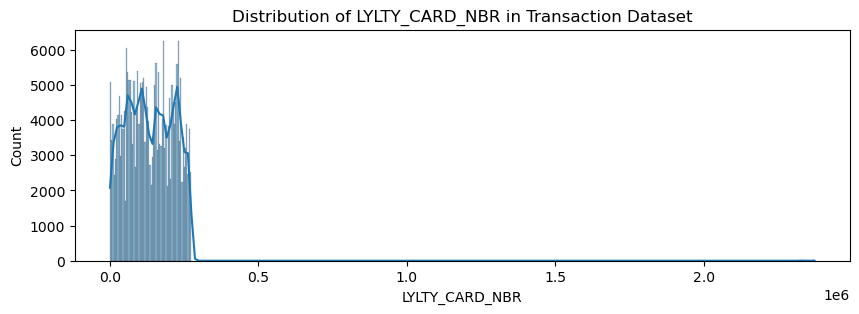

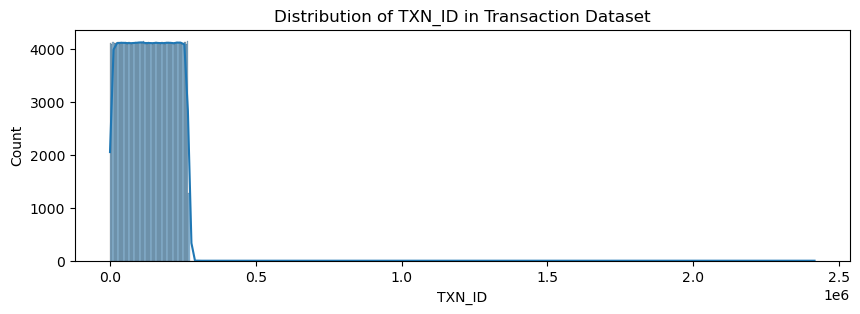

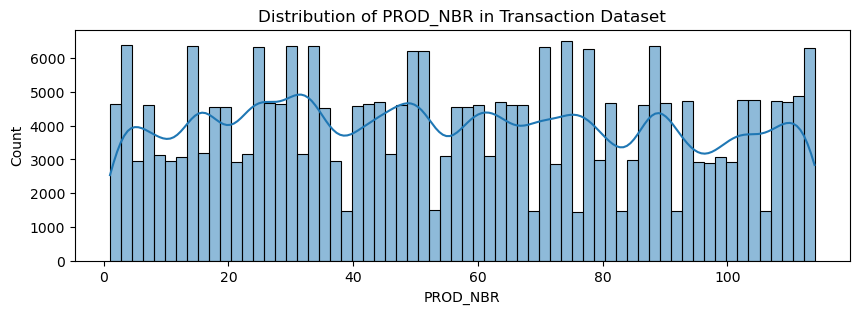

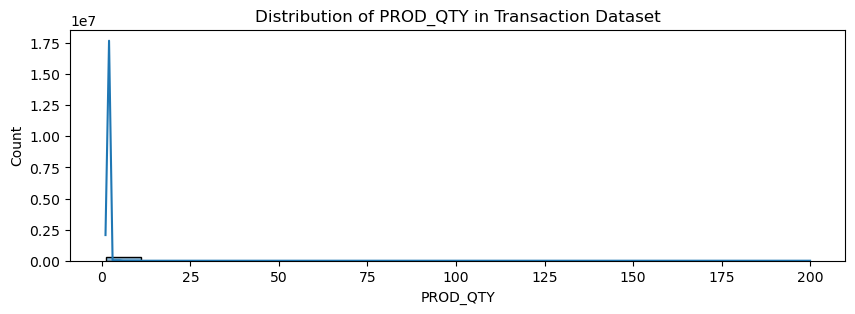

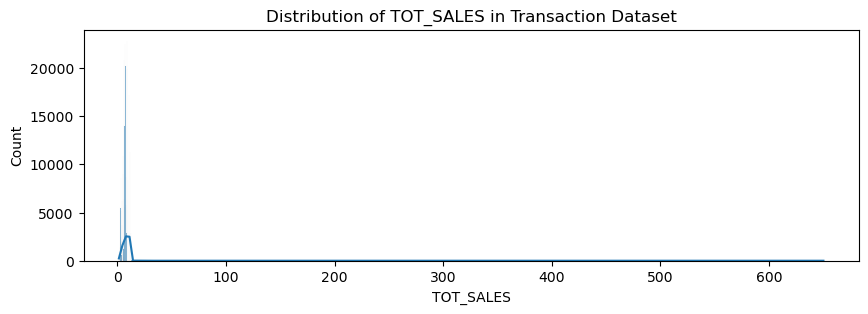

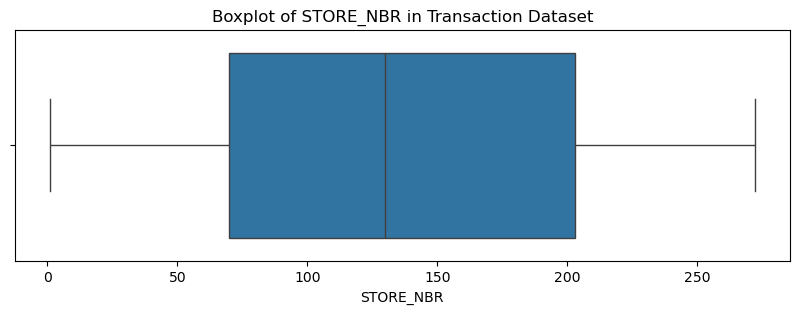

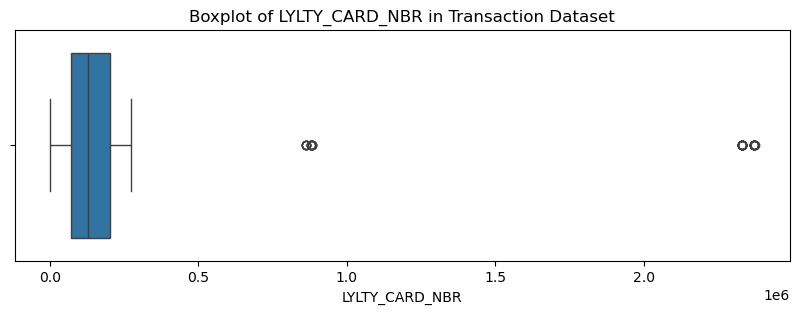

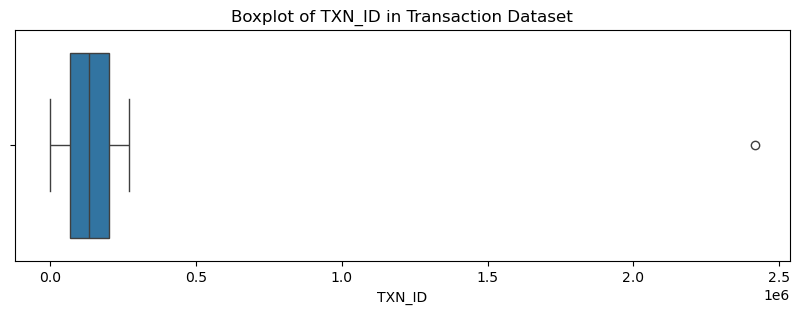

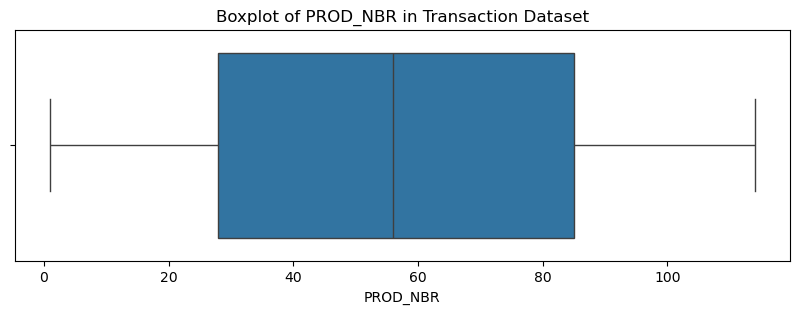

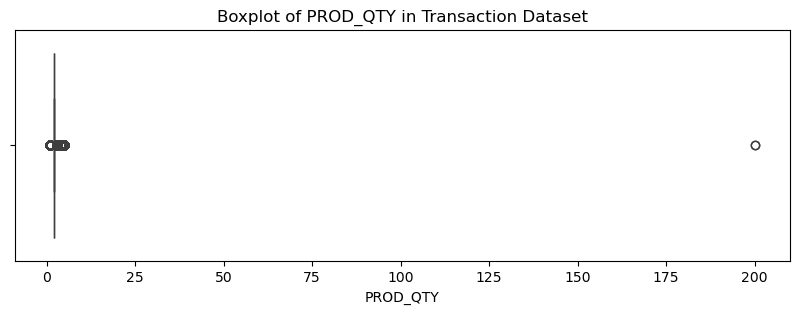

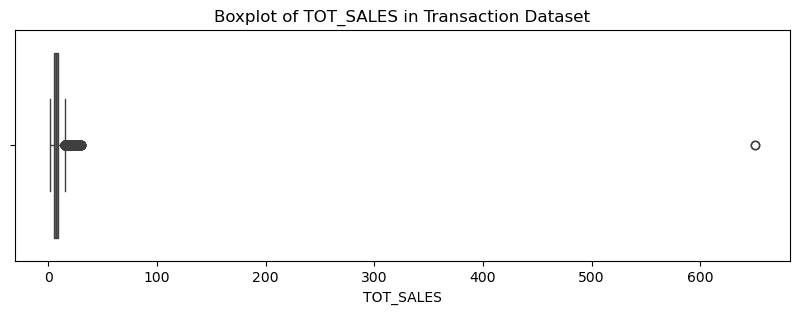

In [19]:
ph_numeric= PH.select_dtypes(include=[np.number])
hd_numeric= HD.select_dtypes(include=[np.number])
for col in ph_numeric.columns:
    plt.figure(figsize=(10,3))
    sns.histplot(data=ph_numeric, x=col, kde=True)
    plt.title(f'Distribution of {col} in Purchase Behaviour Dataset')
    plt.show()
for col in ph_numeric.columns:
    plt.figure(figsize=(10,3))
    sns.boxplot(data=ph_numeric, x=col)
    plt.title(f'Boxplot of {col} in Purchase Behaviour Dataset')
    plt.show()
for col in hd_numeric.columns:
    plt.figure(figsize=(10,3))
    sns.histplot(data=hd_numeric, x=col, kde=True)
    plt.title(f'Distribution of {col} in Transaction Dataset')
    plt.show()
for col in hd_numeric.columns:
    plt.figure(figsize=(10,3))
    sns.boxplot(data=hd_numeric, x=col)
    plt.title(f'Boxplot of {col} in Transaction Dataset')
    plt.show()

#### Remove Outliers

In [20]:
#Found outliersin prod_qty in transaction dataset which is has 200 as max value
#identified outliers and removed them
outliers_transaction = HD[HD['PROD_QTY'] > 100]
print("Outliers in Transaction Dataset based on PROD_QTY:")
display(outliers_transaction)


Outliers in Transaction Dataset based on PROD_QTY:


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


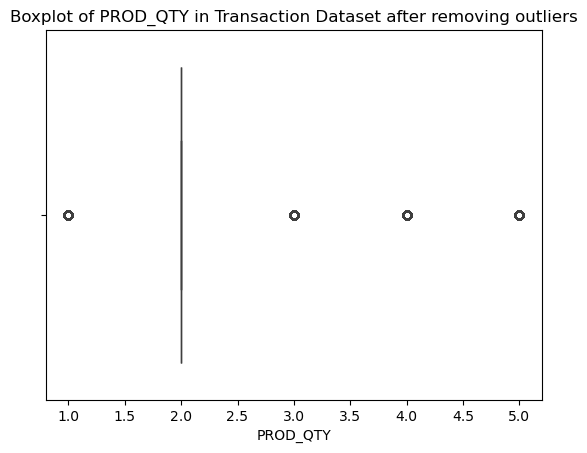

In [21]:
HD = HD[HD['PROD_QTY'] <= 100] #cleaning the outliers
sns.boxplot(data=HD, x='PROD_QTY')
plt.title('Boxplot of PROD_QTY in Transaction Dataset after removing outliers')
plt.show()

#### Chips data only

In [22]:
# Remove another product execpt chips, then remove salsa 
print("Unique products before filtering:", HD['PROD_NAME'].str.contains("salsa", case=False).sum())
# Hapus baris yang mengandung kata "salsa" (case insensitive)
HD_Clean = HD[~HD['PROD_NAME'].str.contains("salsa", case=False)]

print("Jumlah baris setelah Salsa dibuang:", len(HD_Clean))

Unique products before filtering: 18094
Jumlah baris setelah Salsa dibuang: 246740


#### Missing Date

,DATE,TXN_ID
0,2018-07-01,663
1,2018-07-02,650
2,2018-07-03,674
3,2018-07-04,669
4,2018-07-05,660


Tanggal toko tutup:


,DATE,TXN_ID
177,2018-12-25,0.0


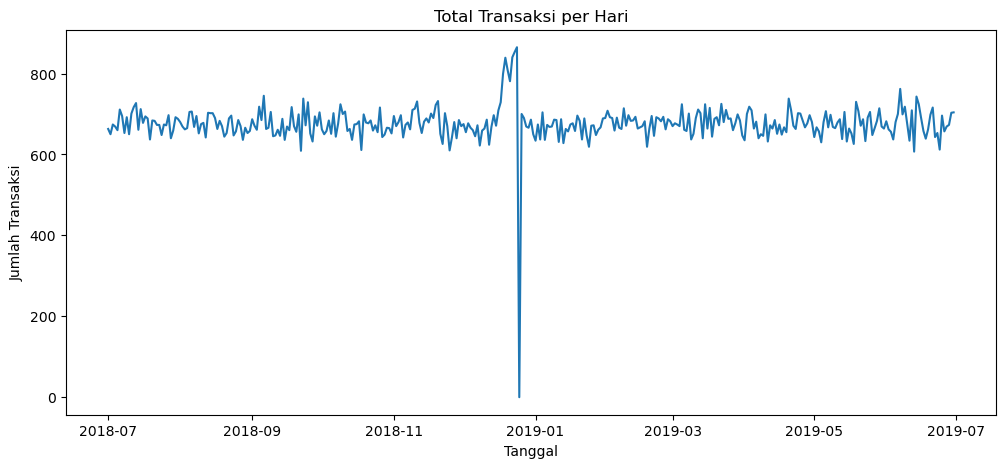

In [23]:
# Hitung jumlah transaksi per hari
txn_per_day = HD_Clean.groupby('DATE').count()['TXN_ID'].reset_index()
display(txn_per_day.head())
# Buat rentang tanggal lengkap setahun (1 Juli 2018 - 30 Juni 2019)
full_date_range = pd.DataFrame({'DATE': pd.date_range(start='2018-07-01', end='2019-06-30')})
# Gabungkan untuk melihat tanggal yang bolong
txn_complete = pd.merge(full_date_range, txn_per_day, on='DATE', how='left')

# Isi NaN dengan 0 (artinya tidak ada transaksi di hari itu)
txn_complete['TXN_ID'].fillna(0, inplace=True)
# Cek tanggal mana yang transaksinya 0
print("Tanggal toko tutup:")
display(txn_complete[txn_complete['TXN_ID'] == 0])

# Plotting Graph (Zoom ke Desember)
import matplotlib.pyplot as plt
import datetime

plt.figure(figsize=(12,5))
plt.plot(txn_complete['DATE'], txn_complete['TXN_ID'])
plt.title("Total Transaksi per Hari")
plt.xlabel("Tanggal")
plt.ylabel("Jumlah Transaksi")
plt.show()

### Feature Engineering

### Get Pack Size

count    264834.000000
mean        182.425512
std          64.325148
min          70.000000
25%         150.000000
50%         170.000000
75%         175.000000
max         380.000000
Name: PACK_SIZE, dtype: float64

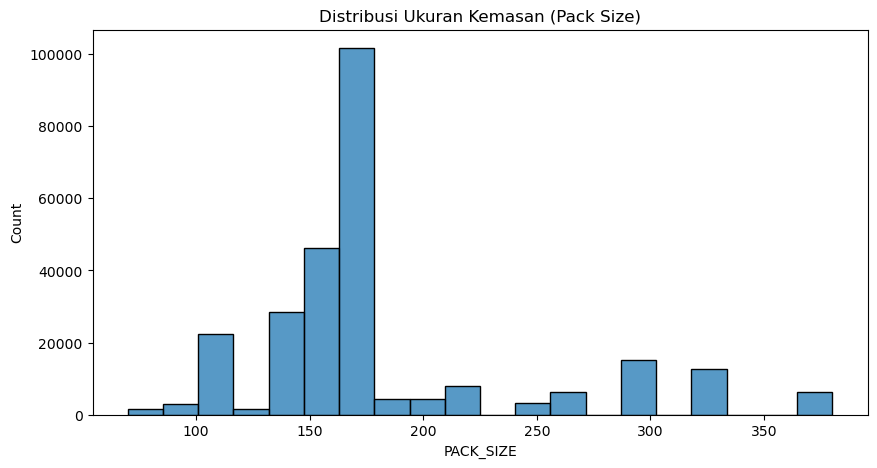

In [ ]:
import re
# --- 1. AMBIL UKURAN KEMASAN (PACK SIZE) ---
# Mengambil angka digit dari string PROD_NAME
# (\d+) adalah regex untuk mencari angka
HD['PACK_SIZE'] = HD['PROD_NAME'].str.extract('(\d+)')
HD['PACK_SIZE'] = pd.to_numeric(HD['PACK_SIZE'])
display(HD['PACK_SIZE'].describe())

# Plot distribusi Pack Size
plt.figure(figsize=(10,5))
sns.histplot(HD['PACK_SIZE'], bins=20)
plt.title("Distribusi Ukuran Kemasan (Pack Size)")
plt.show()

#### Get Brand Name

In [25]:
# Ambil kata pertama dari PROD_NAME sebagai nama brand
HD['BRAND'] = HD['PROD_NAME'].str.split().str[0]
display(HD['BRAND'])

0          Natural
1              CCs
2           Smiths
3           Smiths
4           Kettle
            ...   
264831      Kettle
264832    Tostitos
264833     Doritos
264834     Doritos
264835    Tostitos
Name: BRAND, Length: 264834, dtype: object

List Brand Unik setelah Cleaning:


array(['Natural', 'CCs', 'Smiths', 'Kettle', 'Old', 'Grain', 'Doritos',
       'Twisties', 'WOOLWORTHS', 'Thins', 'Burger', 'NATURAL', 'Cheezels',
       'Infzns', 'Red', 'Pringles', 'Dorito', 'Infuzions', 'Smith',
       'GrnWves', 'Tyrrells', 'Cobs', 'Woolworths', 'French', 'RRD',
       'Tostitos', 'Cheetos', 'Snbts', 'Sunbites'], dtype=object)

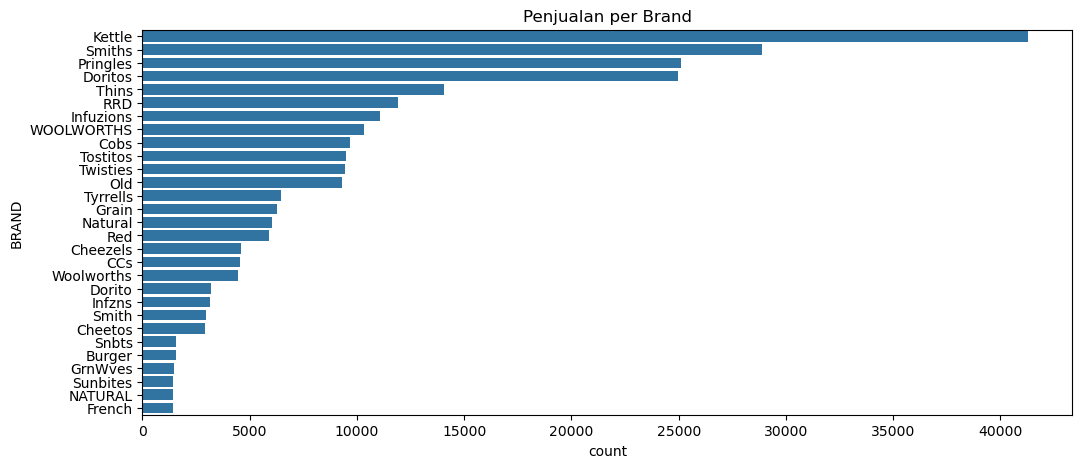

In [27]:
# Cleaning Brand Names
brand_mapping = {
    'RED': 'RRD',           # Red Rock Deli
    'SNBTS': 'SUNBITES',    # Sunbites
    'INFZNS': 'INFUZIONS',  # Infuzions
    'WW': 'WOOLWORTHS',     # Woolworths
    'SMITH': 'SMITHS',      # Smiths
    'NCC': 'NATURAL',       # Natural Chip Co
    'DORITO': 'DORITOS',    # Doritos
    'GRAIN': 'GRNWVES'      # Grain Waves
}
# Terapkan perbaikan nama brand
HD['BRAND'] = HD['BRAND'].replace(brand_mapping)
# Cek hasil cleaning brand
print("List Brand Unik setelah Cleaning:")
display(HD['BRAND'].unique())
# Cek distribusi brand (Siapa paling laku?)
plt.figure(figsize=(12,5))
# Order by count descending agar rapi
sns.countplot(y=HD['BRAND'], order=HD['BRAND'].value_counts().index)
plt.title("Penjualan per Brand")
plt.show()

### Merged Data

In [28]:
# --- 1. MERGE DATA (LEFT JOIN) ---
# Kita gunakan 'left join' karena kita ingin mempertahankan semua data transaksi
# dan hanya menempelkan info customer yang cocok.
dataset = pd.merge(HD, PH, on='LYLTY_CARD_NBR', how='left')

# --- 2. SANITY CHECK (WAJIB!) ---
# Cek apakah jumlah baris berubah? (Harusnya TIDAK boleh berubah)
print(f"Jumlah baris Transaksi Asli (HD): {len(HD)}")
print(f"Jumlah baris Setelah Merge (dataset): {len(dataset)}")

# Cek apakah ada transaksi yang tidak punya info customer? (Harusnya 0)
missing_cust = dataset['LIFESTAGE'].isnull().sum()
print(f"Transaksi tanpa info customer: {missing_cust}")

# Intip hasilnya
display(dataset.head())

Jumlah baris Transaksi Asli (HD): 264834
Jumlah baris Setelah Merge (dataset): 264834
Transaksi tanpa info customer: 0


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,Natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,Kettle,MIDAGE SINGLES/COUPLES,Budget


## Analysis Behavior Chips

### Most Sales by Customer Behavior Segmentation

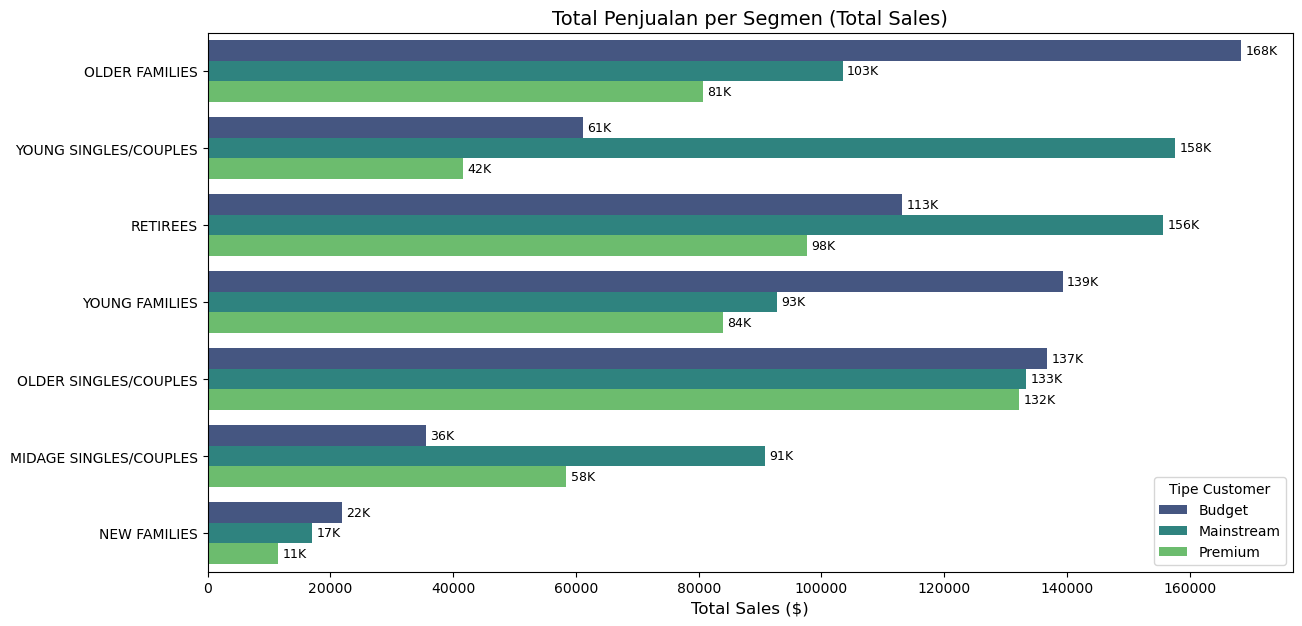

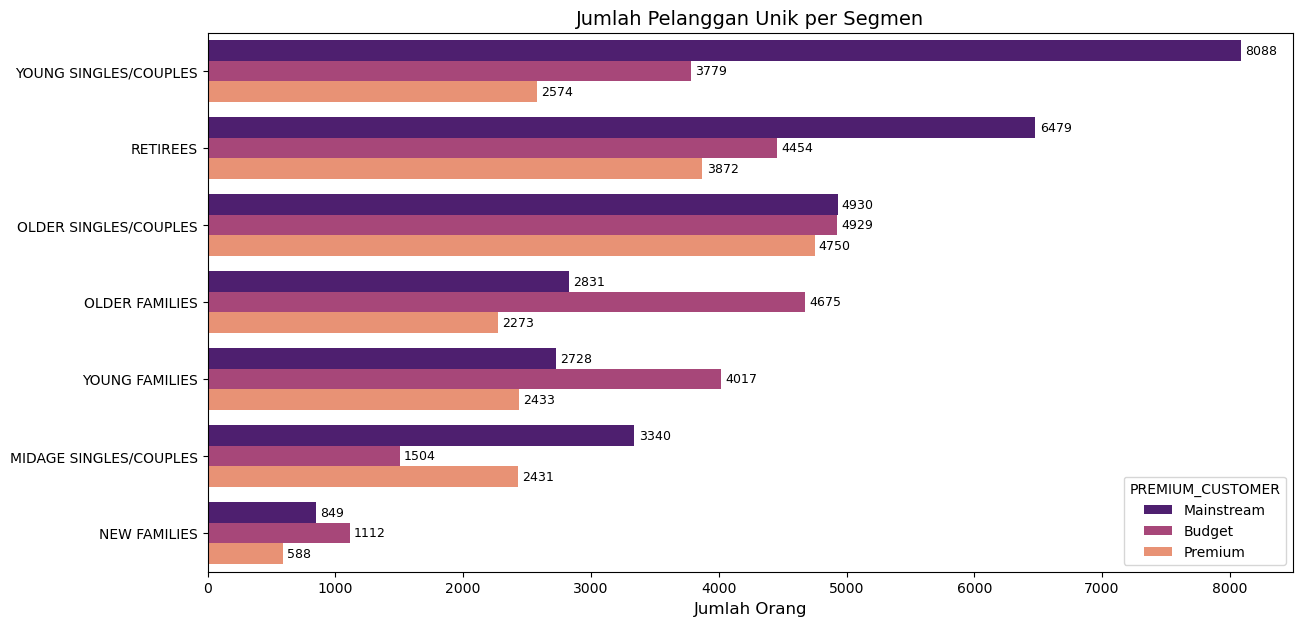

In [29]:
# Fungsi helper untuk menambah label angka di atas batang
def add_labels(ax):
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=3, fontsize=9) # %.0f untuk angka bulat

# --- A. TOTAL SALES per SEGMENT (Siapa penyumbang uang terbanyak?) ---
sales_summary = dataset.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()

plt.figure(figsize=(14, 7))
ax1 = sns.barplot(data=sales_summary.sort_values('TOT_SALES', ascending=False),
                 y='LIFESTAGE', x='TOT_SALES', hue='PREMIUM_CUSTOMER', palette='viridis')

plt.title('Total Penjualan per Segmen (Total Sales)', fontsize=14)
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('')
plt.legend(title='Tipe Customer')

# Tambahkan label (karena angkanya besar, kita format ribuan "K" biar rapi)
for container in ax1.containers:
    ax1.bar_label(container, fmt=lambda x: f'{x/1000:.0f}K', padding=3, fontsize=9)

plt.show()

# --- B. JUMLAH CUSTOMER per SEGMENT (Apakah mereka menang karena banyak orang?) ---
cust_summary = dataset.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().reset_index()

plt.figure(figsize=(14, 7))
ax2 = sns.barplot(data=cust_summary.sort_values('LYLTY_CARD_NBR', ascending=False),
                 y='LIFESTAGE', x='LYLTY_CARD_NBR', hue='PREMIUM_CUSTOMER', palette='magma')

plt.title('Jumlah Pelanggan Unik per Segmen', fontsize=14)
plt.xlabel('Jumlah Orang', fontsize=12)
plt.ylabel('')
add_labels(ax2) # Panggil fungsi label

plt.show()

### Customer Behavior by unit and  price

,LIFESTAGE,PREMIUM_CUSTOMER,AVG_UNIT
0,MIDAGE SINGLES/COUPLES,Budget,6.313830
1,MIDAGE SINGLES/COUPLES,Mainstream,6.796108
2,MIDAGE SINGLES/COUPLES,Premium,6.386672
3,NEW FAMILIES,Budget,5.009892
4,NEW FAMILIES,Mainstream,5.087161


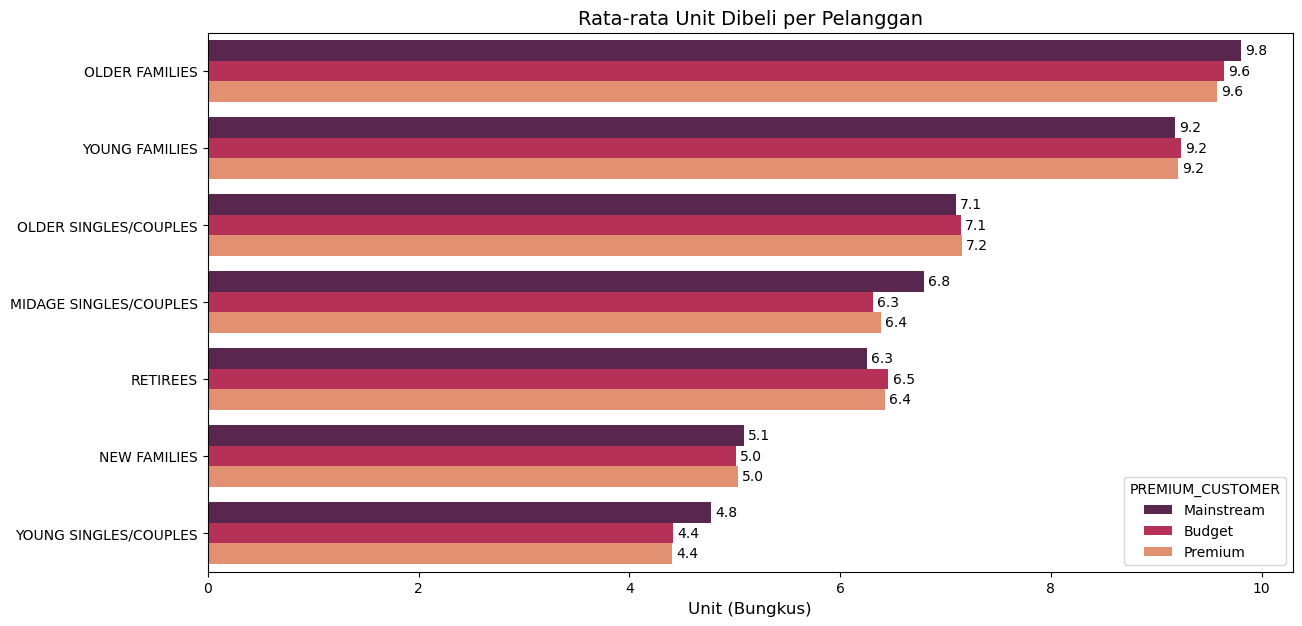

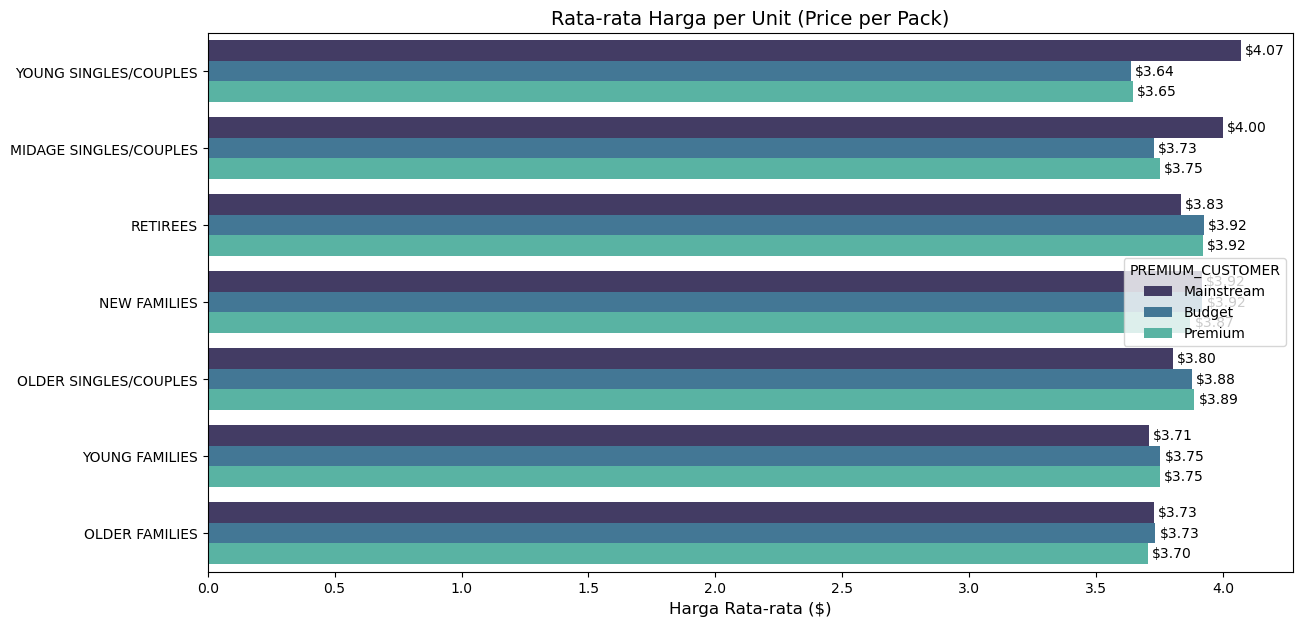

In [32]:
# --- C. RATA-RATA UNIT per CUSTOMER (Siapa yang borong banyak bungkus?) ---
avg_units = dataset.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).apply(
    lambda x: x['PROD_QTY'].sum() / x['LYLTY_CARD_NBR'].nunique()
).reset_index(name='AVG_UNIT')
display(avg_units.head())
plt.figure(figsize=(14, 7))
ax3 = sns.barplot(data=avg_units.sort_values('AVG_UNIT', ascending=False),
                 y='LIFESTAGE', x='AVG_UNIT', hue='PREMIUM_CUSTOMER', palette='rocket')

plt.title('Rata-rata Unit Dibeli per Pelanggan', fontsize=14)
plt.xlabel('Unit (Bungkus)', fontsize=12)
plt.ylabel('')

# Label dengan 1 angka di belakang koma (misal 1.9)
for container in ax3.containers:
    ax3.bar_label(container, fmt='%.1f', padding=3, fontsize=10)

plt.show()

# --- D. RATA-RATA HARGA per UNIT (Siapa yang beli keripik mahal?) ---
# Hitung harga per bungkus dulu
dataset['UNIT_PRICE'] = dataset['TOT_SALES'] / dataset['PROD_QTY']

# Rata-rata per segmen
avg_price = dataset.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['UNIT_PRICE'].mean().reset_index()

plt.figure(figsize=(14, 7))
ax4 = sns.barplot(data=avg_price.sort_values('UNIT_PRICE', ascending=False),
                 y='LIFESTAGE', x='UNIT_PRICE', hue='PREMIUM_CUSTOMER', palette='mako')

plt.title('Rata-rata Harga per Unit (Price per Pack)', fontsize=14)
plt.xlabel('Harga Rata-rata ($)', fontsize=12)
plt.ylabel('')

# Label dengan 2 angka di belakang koma ($3.80)
for container in ax4.containers:
    ax4.bar_label(container, fmt='$%.2f', padding=3, fontsize=10)

plt.show()

### T-Test 

In [33]:
from scipy.stats import ttest_ind

# Definisikan Kelompok Mainstream (Anak Muda & Paruh Baya)
mainstream = dataset[
    (dataset['PREMIUM_CUSTOMER'] == 'Mainstream') &
    (dataset['LIFESTAGE'].isin(['YOUNG SINGLES/COUPLES', 'MIDAGE SINGLES/COUPLES']))
]['UNIT_PRICE']

# Definisikan Kelompok Non-Mainstream (Budget & Premium di umur yang sama)
non_mainstream = dataset[
    (dataset['PREMIUM_CUSTOMER'] != 'Mainstream') &
    (dataset['LIFESTAGE'].isin(['YOUNG SINGLES/COUPLES', 'MIDAGE SINGLES/COUPLES']))
]['UNIT_PRICE']

# Lakukan T-Test
t_stat, p_val = ttest_ind(mainstream, non_mainstream)

print("--- HASIL UJI STATISTIK (T-TEST) ---")
print(f"Rata-rata Harga Mainstream: ${mainstream.mean():.4f}")
print(f"Rata-rata Harga Non-Mainstream: ${non_mainstream.mean():.4f}")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val}")

print("\nKESIMPULAN:")
if p_val < 0.05:
    print("✅ Perbedaan Signifikan! Segmen Mainstream TERBUKTI membeli keripik yang lebih mahal.")
else:
    print("❌ Tidak ada perbedaan signifikan.")

--- HASIL UJI STATISTIK (T-TEST) ---
Rata-rata Harga Mainstream: $4.0456
Rata-rata Harga Non-Mainstream: $3.6882
T-Statistic: 40.8341
P-Value: 0.0

KESIMPULAN:
✅ Perbedaan Signifikan! Segmen Mainstream TERBUKTI membeli keripik yang lebih mahal.


#### Affinity Analysis

In [34]:
# --- DEEP DIVE: AFFINITY ANALYSIS ---
# Target: Mainstream - Young Singles/Couples
# Kita ingin tahu: Brand apa yang LEBIH sering mereka beli dibanding orang lain?

# 1. Pisahkan Target Segment vs Others
target_segment = dataset[
    (dataset['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & 
    (dataset['PREMIUM_CUSTOMER'] == 'Mainstream')
]
other_segment = dataset[
    ~((dataset['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & 
      (dataset['PREMIUM_CUSTOMER'] == 'Mainstream'))
]

# 2. Hitung Total Quantity
qty_target = target_segment['PROD_QTY'].sum()
qty_other = other_segment['PROD_QTY'].sum()

# 3. Hitung Proporsi per Brand untuk Target
target_brand = target_segment.groupby('BRAND')['PROD_QTY'].sum() / qty_target
target_brand = target_brand.reset_index(name='target_prop')

# 4. Hitung Proporsi per Brand untuk Others
other_brand = other_segment.groupby('BRAND')['PROD_QTY'].sum() / qty_other
other_brand = other_brand.reset_index(name='other_prop')

# 5. Gabungkan dan Hitung Affinity (Target / Other)
brand_affinity = pd.merge(target_brand, other_brand, on='BRAND')
brand_affinity['affinity'] = brand_affinity['target_prop'] / brand_affinity['other_prop']

# Tampilkan Top 5 Brand Favorit Target
print("\n--- BRAND AFFINITY (Mainstream Young Singles/Couples) ---")
display(brand_affinity.sort_values('affinity', ascending=False).head())

# --- ULANGI UNTUK PACK SIZE ---
# 6. Hitung Proporsi per Pack Size
target_pack = target_segment.groupby('PACK_SIZE')['PROD_QTY'].sum() / qty_target
other_pack = other_segment.groupby('PACK_SIZE')['PROD_QTY'].sum() / qty_other

target_pack = target_pack.reset_index(name='target_prop')
other_pack = other_pack.reset_index(name='other_prop')

# 7. Hitung Affinity Pack Size
pack_affinity = pd.merge(target_pack, other_pack, on='PACK_SIZE')
pack_affinity['affinity'] = pack_affinity['target_prop'] / pack_affinity['other_prop']

print("\n--- PACK SIZE AFFINITY ---")
display(pack_affinity.sort_values('affinity', ascending=False).head())


--- BRAND AFFINITY (Mainstream Young Singles/Couples) ---


,BRAND,target_prop,other_prop,affinity
5,Dorito,0.014729,0.011886,1.239159
26,Tyrrells,0.029587,0.023933,1.236235
25,Twisties,0.043306,0.035283,1.227401
12,Kettle,0.185649,0.154216,1.203823
24,Tostitos,0.042581,0.035377,1.203638



--- PACK SIZE AFFINITY ---


,PACK_SIZE,target_prop,other_prop,affinity
17,270,0.029846,0.023377,1.276694
20,380,0.030156,0.023832,1.265361
19,330,0.057465,0.046727,1.229814
4,134,0.111980,0.093743,1.194536
2,110,0.099658,0.083642,1.191482


# RECOMMENDATION TO JULIA (Category Manager):

Target Segment: Focus on young singles/couples because they are the biggest contributors to sales and most willing to pay high prices (average price of $4.04 vs. $3.68 for others).

Product Placement:  

Place Tyrrells and Twisties (especially the 270g size) in highly visible areas (out-of-reach displays) that are frequently passed by young people.  

This segment has proven to be impulsive (Impulsive Buyers), so the visibility of premium products is crucial.  

Promotions: Avoid offering frequent discounts on premium products for this segment, as they are not price-sensitive. Use package promotions only.

Translated with DeepL.com (free version)